# XGBoost Classifier

- XGBoost: builds an ensemble of decision trees sequentially, where each new tree corrects the errors of the previous ones
- Generally more accurate than a single Decision Tree, but less easy to interpret
- Dataset: Social_Network_Ads.csv (predicting Purchased)
          [https://www.kaggle.com/code/swahajraza/social-network-ads/input](https://)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Social_Network_Ads.csv')
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


## Model Building
problem statement -  The goal is to build a Decision Tree classifier that predicts whether a new user will purchase the product based on their Age and Estimated Salary

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

x = df.drop('Purchased', axis = 1)
y = df['Purchased']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

model = XGBClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('actual y values :',  y_test.values)
print('predicted y values :', y_pred)

print('accuracy score :', accuracy_score(y_test, y_pred))
print('confusion matrix :', confusion_matrix(y_test, y_pred))
print('classification report :', classification_report(y_test, y_pred))

actual y values : [0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0
 1 0 1 1 0 1]
predicted y values : [1 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 1 0 1 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0
 1 0 1 1 0 0]
accuracy score : 0.9
confusion matrix : [[46  6]
 [ 2 26]]
classification report :               precision    recall  f1-score   support

           0       0.96      0.88      0.92        52
           1       0.81      0.93      0.87        28

    accuracy                           0.90        80
   macro avg       0.89      0.91      0.89        80
weighted avg       0.91      0.90      0.90        80



### Feature Importance
Let's examine the importance of each feature in the XGBoost model.

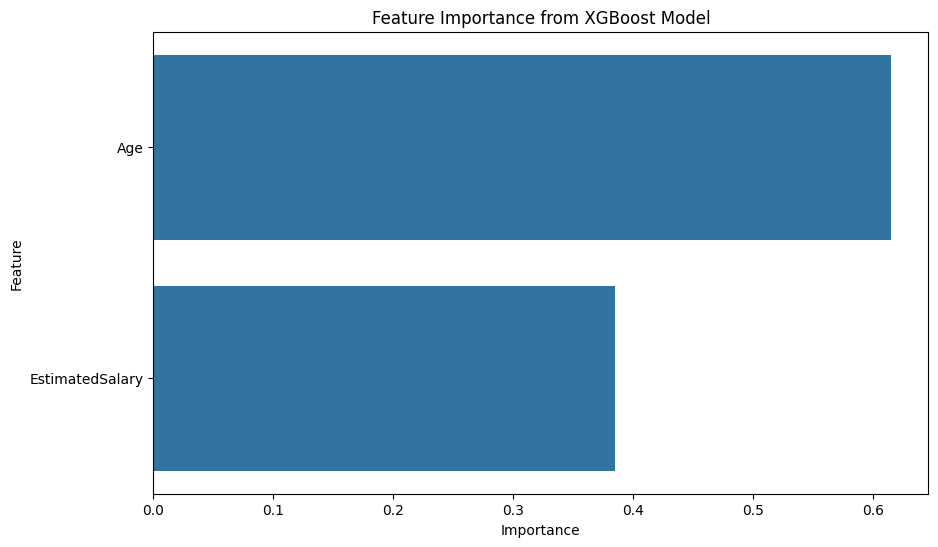

In [6]:
feature_importances = model.feature_importances_
feature_names = x.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Visualize a Decision Tree
To visualize one of the decision trees within the XGBoost model, we'll need to install `graphviz`.

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


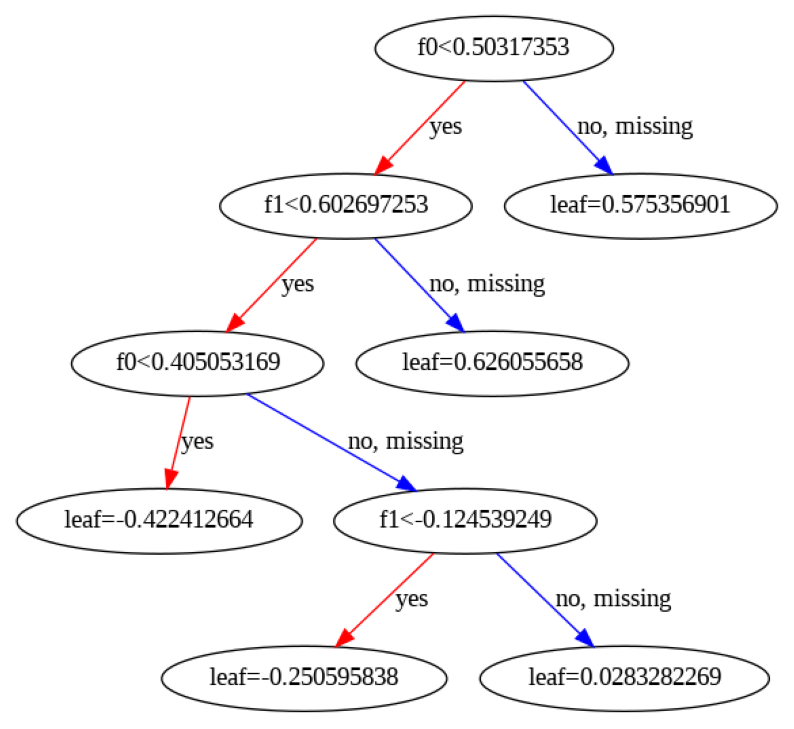

In [8]:
# Install graphviz for tree visualization (if not already installed)
!pip install graphviz

import graphviz
from xgboost import plot_tree

# Plot the first tree in the ensemble (you can change num_trees if you want to see a different one)
fig, ax = plt.subplots(figsize=(10, 18))
plot_tree(model, num_trees=0, ax=ax)
plt.show()

## Conclusion
- XGBoost combines many small decision trees, where each tree learns from the mistakes of the previous ones (boosting)
- Confusion Matrix & Accuracy show how well it predicted on unseen test data
- Feature importance shows which feature (Age vs EstimatedSalary) contributed more to the predictions
- Usually performs better than a single Decision Tree, especially on larger/more complex datasets